In [1]:
!pip install torch tqdm scikit-learn joblib pandas pyarrow -q

import os
import sys
import json
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import joblib
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
from typing import Tuple, Optional
import warnings

warnings.filterwarnings('ignore')

# Check GPU availability
print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Device: Tesla T4


In [17]:
#============================================================================
# KAGGLE CONFIGURATION - CORRECTED PATHS
# ============================================================================

# Paths - Use the actual Kaggle dataset path
DATA_DIR = "/kaggle/input/datasets/etj7756/igia-rvr-residual-lstm/igia-rvr-residual-lstm"
OUTPUT_DIR = "/kaggle/working"

DATASET_PATH = f"{DATA_DIR}/igia_rvr_training_dataset_multi.parquet"
SCALER_X_PATH = f"{DATA_DIR}/scaler_X.pkl"
SCALER_Y_PATH = f"{DATA_DIR}/scaler_y.pkl"

# Create output directories
os.makedirs(f"{OUTPUT_DIR}/checkpoints", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/logs", exist_ok=True)

# ============================================================================
# DATASET CONFIGURATION
# ============================================================================
TRAIN_START = "2019-09-18"
TRAIN_END = "2023-12-31"
VAL_START = "2024-01-01"
VAL_END = "2024-12-31"
TEST_START = "2025-01-01"
TEST_END = "2025-12-31"

# ============================================================================
# TEMPORAL CONFIGURATION
# ============================================================================
LOOKBACK = 36
STEP_SIZE = 10
ZONES = ["09_TDZ", "10_TDZ", "11_BEG", "11_TDZ", "27_TDZ",
         "28_TDZ", "29_BEG", "29_TDZ", "MID_2810", "MID_2911"]
HORIZONS = ["10m", "30m", "1h", "3h", "6h"]
NUM_ZONES = len(ZONES)
NUM_HORIZONS = len(HORIZONS)
OUTPUT_SIZE = NUM_ZONES * NUM_HORIZONS

# ============================================================================
# FEATURE CONFIGURATION
# ============================================================================
NUM_INPUT_FEATURES = 104

# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================
HIDDEN_SIZE = 256
NUM_LSTM_LAYERS = 3
DROPOUT = 0.3
BIDIRECTIONAL = False

# ============================================================================
# TRAINING CONFIGURATION
# ============================================================================
BATCH_SIZE = 128
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
GRADIENT_CLIP = 1.0
LOSS_FUNCTION = "MAE"

# ============================================================================
# DEVICE & CHECKPOINTING
# ============================================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINTS_DIR = f"{OUTPUT_DIR}/checkpoints"
LOG_DIR = f"{OUTPUT_DIR}/logs"
SAVE_FREQ = 5
VAL_INTERVAL = 1

print(f"Using device: {DEVICE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Num epochs: {NUM_EPOCHS}")
print(f"Dataset path: {DATASET_PATH}")
print(f"Scaler X path: {SCALER_X_PATH}")
print(f"Scaler Y path: {SCALER_Y_PATH}")


Using device: cuda
Batch size: 128
Num epochs: 100
Dataset path: /kaggle/input/datasets/etj7756/igia-rvr-residual-lstm/igia-rvr-residual-lstm/igia_rvr_training_dataset_multi.parquet
Scaler X path: /kaggle/input/datasets/etj7756/igia-rvr-residual-lstm/igia-rvr-residual-lstm/scaler_X.pkl
Scaler Y path: /kaggle/input/datasets/etj7756/igia-rvr-residual-lstm/igia-rvr-residual-lstm/scaler_y.pkl


In [6]:
## *KAGGLE CELL 3: Custom Dataset Class*

class RVRSequenceDataset(torch.utils.data.Dataset):
    """Custom PyTorch Dataset for RVR forecasting"""
    
    def __init__(self, data, scaler_X, scaler_y, lookback=36, 
                 feature_columns=None, target_columns=None, split='train'):
        
        self.lookback = lookback
        self.split = split
        
        split_dates = {
            'train': ("2019-09-18", "2023-12-31"),
            'val': ("2024-01-01", "2024-12-31"),
            'test': ("2025-01-01", "2025-12-31")
        }
        
        start_date, end_date = split_dates[split]
        mask = (data.index >= start_date) & (data.index <= end_date)
        self.data_split = data[mask].reset_index(drop=True)
        
        # Use scaler's feature names
        if hasattr(scaler_X, 'feature_names_in_'):
            self.feature_columns = list(scaler_X.feature_names_in_)
        else:
            self.feature_columns = feature_columns or self._get_feature_columns(data)
        
        self.target_columns = target_columns or self._get_target_columns(data)
        
        self.X = self.data_split[self.feature_columns].values.astype(np.float32)
        self.y = self.data_split[self.target_columns].values.astype(np.float32)
        
        self.scaler_X = scaler_X
        self.scaler_y = scaler_y
        
        self.X_scaled = self.scaler_X.transform(self.X).astype(np.float32)
        self.y_scaled = self.scaler_y.transform(self.y).astype(np.float32)
        
        print(f"[{split.upper()}] Loaded {len(self.X)} steps, {len(self)} sequences")
    
    @staticmethod
    def _get_feature_columns(data):
        return [col for col in data.columns if not col.startswith('target_')]
    
    @staticmethod
    def _get_target_columns(data):
        return sorted([col for col in data.columns if col.startswith('target_')])
    
    def __len__(self):
        return len(self.X) - self.lookback
    
    def __getitem__(self, idx):
        X_seq = self.X_scaled[idx : idx + self.lookback]
        y_target = self.y_scaled[idx + self.lookback - 1]
        return torch.from_numpy(X_seq), torch.from_numpy(y_target)


def create_dataloaders(dataset_path, scaler_X_path, scaler_y_path,
                       lookback=36, batch_size=128, num_workers=2, pin_memory=True):
    """Create DataLoaders for train/val/test"""
    
    print("Loading dataset...")
    data = pd.read_parquet(dataset_path)
    data.index = pd.to_datetime(data.index)
    
    print("Loading scalers...")
    scaler_X = joblib.load(scaler_X_path)
    scaler_y = joblib.load(scaler_y_path)
    
    feature_cols = list(scaler_X.feature_names_in_)
    target_cols = sorted([col for col in data.columns if col.startswith('target_')])
    
    num_features = len(feature_cols)
    num_targets = len(target_cols)
    
    print(f"\nDataset Configuration:")
    print(f"  Input Features: {num_features}")
    print(f"  Output Targets: {num_targets}")
    print(f"  Lookback: {lookback} steps")
    
    train_dataset = RVRSequenceDataset(data, scaler_X, scaler_y, lookback, 
                                       feature_cols, target_cols, 'train')
    val_dataset = RVRSequenceDataset(data, scaler_X, scaler_y, lookback,
                                     feature_cols, target_cols, 'val')
    test_dataset = RVRSequenceDataset(data, scaler_X, scaler_y, lookback,
                                      feature_cols, target_cols, 'test')
    
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=pin_memory, drop_last=True)
    val_loader = torch.utils.data.DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory)
    test_loader = torch.utils.data.DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory)
    
    print(f"\nDataLoader Configuration:")
    print(f"  Train batches: {len(train_loader)}")
    print(f"  Val batches: {len(val_loader)}")
    print(f"  Test batches: {len(test_loader)}\n")
    
    return train_loader, val_loader, test_loader, num_features, num_targets


In [7]:
#Cell 4: Model Architecture


class ResidualLSTMBlock(nn.Module):
    """Residual LSTM Block with skip connections"""
    
    def __init__(self, input_size, hidden_size, dropout=0.3, batch_first=True):
        super().__init__()
        self.hidden_size = hidden_size
        self.input_size = input_size
        
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=batch_first,
                           dropout=dropout if dropout > 0 else 0.0)
        
        if input_size != hidden_size:
            self.residual_proj = nn.Linear(input_size, hidden_size)
        else:
            self.residual_proj = None
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, h_state=None):
        lstm_out, (h, c) = self.lstm(x, h_state)
        
        if self.residual_proj is not None:
            residual = self.residual_proj(x)
        else:
            residual = x
        
        output = lstm_out + residual
        output = self.dropout(output)
        
        return output, (h, c)


class MultiHorizonResidualLSTM(nn.Module):
    """Multi-Horizon Residual LSTM for RVR Forecasting"""
    
    def __init__(self, input_size, hidden_size=256, num_layers=3,
                 dropout=0.3, output_size=50, projection_hidden_1=512,
                 projection_hidden_2=256):
        super().__init__()
        
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size
        
        self.lstm_blocks = nn.ModuleList()
        for layer_idx in range(num_layers):
            layer_input_size = input_size if layer_idx == 0 else hidden_size
            block = ResidualLSTMBlock(layer_input_size, hidden_size, dropout)
            self.lstm_blocks.append(block)
        
        self.projection_head = nn.Sequential(
            nn.Linear(hidden_size, projection_hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(projection_hidden_1, projection_hidden_2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(projection_hidden_2, output_size)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
    
    def forward(self, x):
        batch_size = x.size(0)
        h_states = [None] * self.num_layers
        
        lstm_out = x
        for layer_idx, block in enumerate(self.lstm_blocks):
            lstm_out, h_states[layer_idx] = block(lstm_out, h_states[layer_idx])
        
        last_output = lstm_out[:, -1, :]
        output = self.projection_head(last_output)
        
        return output


# Create model
print("Creating model...")
model = MultiHorizonResidualLSTM(
    input_size=NUM_INPUT_FEATURES,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LSTM_LAYERS,
    dropout=DROPOUT,
    output_size=OUTPUT_SIZE
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}\n")


Creating model...
Total Parameters: 1,726,002
Trainable Parameters: 1,726,002



In [19]:
# Cell 5: Load DataLoaders

print("Loading dataset...")
train_loader, val_loader, test_loader, scaler_X, scaler_y = create_dataloaders(
    dataset_path=DATASET_PATH,
    scaler_X_path=SCALER_X_PATH,
    scaler_y_path=SCALER_Y_PATH,
    batch_size=BATCH_SIZE,
    lookback=36
)

print("\n✓ DataLoaders created successfully!")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Verify batch shapes
X_sample, y_sample = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  Input (X): {X_sample.shape} → (batch_size=128, lookback=36, features=104)")
print(f"  Target (y): {y_sample.shape} → (batch_size=128, horizons=50)")

Loading dataset...
Loading dataset...
Loading scalers...

Dataset Configuration:
  Input Features: 104
  Output Targets: 50
  Lookback: 36 steps
[TRAIN] Loaded 159889 steps, 159853 sequences
[VAL] Loaded 45755 steps, 45719 sequences
[TEST] Loaded 46454 steps, 46418 sequences

DataLoader Configuration:
  Train batches: 1248
  Val batches: 358
  Test batches: 363


✓ DataLoaders created successfully!
  Train batches: 1248
  Val batches: 358
  Test batches: 363

Batch shapes:
  Input (X): torch.Size([128, 36, 104]) → (batch_size=128, lookback=36, features=104)
  Target (y): torch.Size([128, 50]) → (batch_size=128, horizons=50)


In [20]:
# Cell 6: Setup Optimizer, Loss, and Training Functions

# Optimizer and Loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = torch.nn.L1Loss()  # MAE loss
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
)

print("✓ Optimizer: Adam (lr=1e-3, weight_decay=1e-5)")
print("✓ Loss: L1Loss (MAE)")
print("✓ Scheduler: ReduceLROnPlateau (factor=0.5, patience=10)")

# Training function
def train_epoch(model, train_loader, optimizer, criterion, device, gradient_clip=1.0):
    model.train()
    total_loss = 0.0
    
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        
        optimizer.zero_grad()
        predictions = model(X)
        loss = criterion(predictions, y)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

# Validation function
def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            predictions = model(X)
            loss = criterion(predictions, y)
            total_loss += loss.item()
    
    return total_loss / len(val_loader)

# Test function
def test_final(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            predictions = model(X)
            loss = criterion(predictions, y)
            total_loss += loss.item()
    
    return total_loss / len(test_loader)

print("\n✓ Training functions defined")

✓ Optimizer: Adam (lr=1e-3, weight_decay=1e-5)
✓ Loss: L1Loss (MAE)
✓ Scheduler: ReduceLROnPlateau (factor=0.5, patience=10)

✓ Training functions defined


In [21]:
# Cell 7: Main Training Loop with Early Stopping

import time

# Training configuration
num_epochs = NUM_EPOCHS
patience = 20
best_val_loss = float('inf')
patience_counter = 0
start_time = time.time()

print(f"Starting training for {num_epochs} epochs with early stopping (patience={patience})...\n")

history = {
    'train_loss': [],
    'val_loss': [],
    'learning_rate': []
}

for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss = validate(model, val_loader, criterion, DEVICE)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
        }, '/kaggle/working/best_model.pt')
    else:
        patience_counter += 1
    
    # Print progress
    elapsed_mins = (time.time() - start_time) / 60
    print(f"Epoch {epoch:3d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e} | Time: {elapsed_mins:.1f}m")
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered after {epoch} epochs (patience={patience})")
        break

print(f"\n✓ Training complete!")
print(f"  Best validation loss: {best_val_loss:.4f}")
print(f"  Total time: {(time.time() - start_time) / 60:.1f} minutes")

# Load best model and evaluate on test set
model.load_state_dict(torch.load('/kaggle/working/best_model.pt')['model_state_dict'])
test_loss = test_final(model, test_loader, criterion, DEVICE)

print(f"\n✓ Test Results:")
print(f"  Test MAE Loss: {test_loss:.4f} meters")
print(f"  Baseline MAE: 269.0 meters")
if test_loss < 269:
    print(f"  Status: BEAT BASELINE by {269 - test_loss:.2f}m!")
else:
    print(f"  Status: Above baseline by {test_loss - 269:.2f}m")

Starting training for 100 epochs with early stopping (patience=20)...

Epoch   1/100 | Train Loss: 0.3595 | Val Loss: 0.2386 | LR: 1.00e-03 | Time: 0.4m
Epoch   2/100 | Train Loss: 0.2860 | Val Loss: 0.2215 | LR: 1.00e-03 | Time: 0.8m
Epoch   3/100 | Train Loss: 0.2719 | Val Loss: 0.2171 | LR: 1.00e-03 | Time: 1.2m
Epoch   4/100 | Train Loss: 0.2629 | Val Loss: 0.2108 | LR: 1.00e-03 | Time: 1.6m
Epoch   5/100 | Train Loss: 0.2581 | Val Loss: 0.2132 | LR: 1.00e-03 | Time: 2.0m
Epoch   6/100 | Train Loss: 0.2547 | Val Loss: 0.2104 | LR: 1.00e-03 | Time: 2.4m
Epoch   7/100 | Train Loss: 0.2525 | Val Loss: 0.2164 | LR: 1.00e-03 | Time: 2.8m
Epoch   8/100 | Train Loss: 0.2500 | Val Loss: 0.2116 | LR: 1.00e-03 | Time: 3.2m
Epoch   9/100 | Train Loss: 0.2478 | Val Loss: 0.2118 | LR: 1.00e-03 | Time: 3.6m
Epoch  10/100 | Train Loss: 0.2454 | Val Loss: 0.2083 | LR: 1.00e-03 | Time: 4.0m
Epoch  11/100 | Train Loss: 0.2433 | Val Loss: 0.2099 | LR: 1.00e-03 | Time: 4.4m
Epoch  12/100 | Train Loss:

In [23]:
# Cell 8: Evaluate in Original Scale (Meters)

import joblib
import numpy as np

# Reload scalers from files to ensure they're correct
scaler_y = joblib.load(SCALER_Y_PATH)

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(DEVICE)
        preds = model(X).cpu().numpy()
        targets = y.cpu().numpy()
        all_preds.append(preds)
        all_targets.append(targets)

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# Inverse transform to original scale (meters)
all_preds_original = scaler_y.inverse_transform(all_preds)
all_targets_original = scaler_y.inverse_transform(all_targets)

# Compute MAE in meters
test_mae_meters = np.mean(np.abs(all_preds_original - all_targets_original))

print(f"✓ Test MAE (in meters): {test_mae_meters:.2f}m")
print(f"  Baseline MAE: 269.0m")
if test_mae_meters < 269:
    print(f"  Status: BEAT BASELINE by {269 - test_mae_meters:.2f}m!")
else:
    print(f"  Status: Above baseline by {test_mae_meters - 269:.2f}m")

✓ Test MAE (in meters): 137.04m
  Baseline MAE: 269.0m
  Status: BEAT BASELINE by 131.96m!


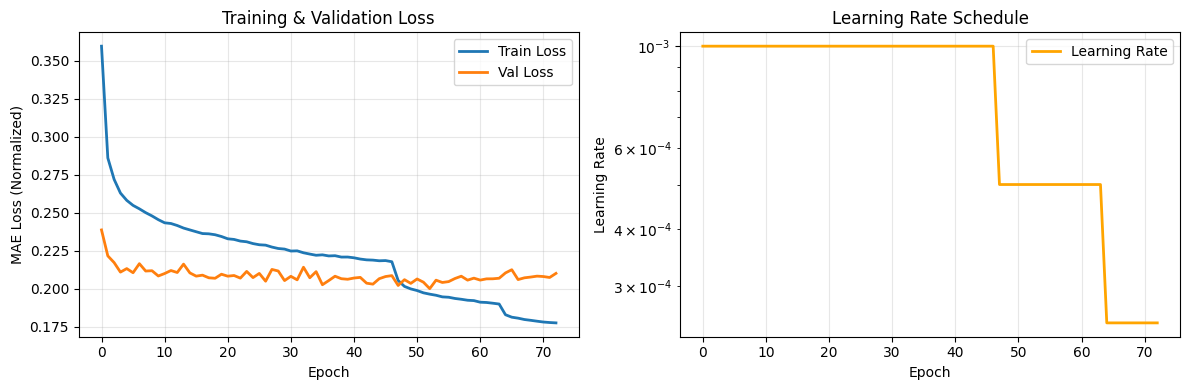

✓ Training curves saved to /kaggle/working/training_curves.png


In [24]:
# Cell 9: Plot Training Curves (Optional)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE Loss (Normalized)')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Learning rate curve
axes[1].plot(history['learning_rate'], label='Learning Rate', linewidth=2, color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate Schedule')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Training curves saved to /kaggle/working/training_curves.png")

In [ ]:
import shutil

output_filename = "kaggle_working_files"

# Zips the folder /kaggle/working
shutil.make_archive(output_filename, 'zip', '/kaggle/working')